Import statements

In [2]:
import pandas as pd
import seaborn as sns
from scipy import stats
import matplotlib.pyplot as plt

## Analysis Technique 1 - CM - What college should I attend to make the most money?

In [33]:
players = pd.read_csv('core/people.csv')
schools = pd.read_csv('core/Schools.csv')
salaries = pd.read_csv('core/Salaries.csv')
college_playing = pd.read_csv('core/CollegePlaying.csv')

In [27]:
# Goal: Group salaries by school. 
# So first I need to make each player have their average salary, 
# and then group players by school and then average the salaries for each school. 
# Then a bar chart with each school (maybe top 10 or something).

playersalaries = players.merge(salaries)
playersalaries = playersalaries.groupby('playerID')
# Calculate the average salary and reset the index to keep it as a clean DataFrame
average_salaries = playersalaries['salary'].mean().reset_index()

average_salaries


,playerID,salary
0,aardsda01,"1,322,821"
1,aasedo01,"575,000"
2,abadan01,"327,000"
3,abadfe01,"753,280"
4,abbotje01,"246,250"
...,...,...
5144,zumayjo01,"701,167"
5145,zuninmi01,"513,800"
5146,zupcibo01,"143,667"
5147,zuvelpa01,"145,000"


In [35]:
# Players often have multiple entries if they played multiple years. 
# Dropping duplicates ensures we just get one school per player.
player_schools = college_playing.drop_duplicates(subset=['playerID'])[['playerID', 'schoolID']]

# Merge using a left join to keep all players, even those without a school
matched_data = pd.merge(average_salaries, player_schools, on='playerID', how='left')

# Replace the missing (NaN) values in the school column with a custom group name
matched_data['schoolID'] = matched_data['schoolID'].fillna('Did Not Attend')

matched_data

,playerID,salary,schoolID
0,aardsda01,"1,322,821",pennst
1,aasedo01,"575,000",Did Not Attend
2,abadan01,"327,000",gamiddl
3,abadfe01,"753,280",Did Not Attend
4,abbotje01,"246,250",kentucky
...,...,...,...
5144,zumayjo01,"701,167",Did Not Attend
5145,zuninmi01,"513,800",florida
5146,zupcibo01,"143,667",oralrob
5147,zuvelpa01,"145,000",stanford


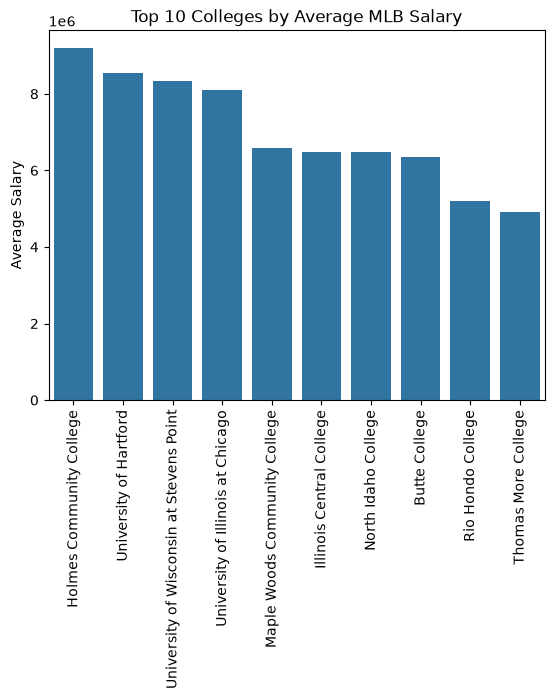

In [40]:
# 1. Group by schoolID to get the average salary
school_groupings = matched_data.groupby('schoolID')['salary'].mean().reset_index()

# 3. Merge with the 'schools' dataframe to pull in the actual school names
school_names_merged = pd.merge(school_groupings, schools[['schoolID', 'name_full']], on='schoolID', how='left')

# 4. Fill the resulting NaN for 'Did Not Attend'
school_names_merged['name_full'] = school_names_merged['name_full'].fillna('Did Not Attend')

# 5. Sort values from highest to lowest salary and grab the top 10
top_10_schools = school_names_merged.sort_values(by='salary', ascending=False).head(10)

# 6. Plot the bar chart using Seaborn
chart = sns.barplot(data=top_10_schools, x='name_full', y='salary')

# # 7. Format the chart directly through the Seaborn axes object
chart.set_title('Top 10 Colleges by Average MLB Salary')
chart.set_ylabel('Average Salary')
chart.set_xlabel('') 

# Rotate the x-axis labels so they don't overlap
chart.tick_params(axis='x', rotation=90)

## Analysis Technique 2 - CM - Are modern pitching techniques better than old pitching techniques?

Text(0.5, 0, 'Year')

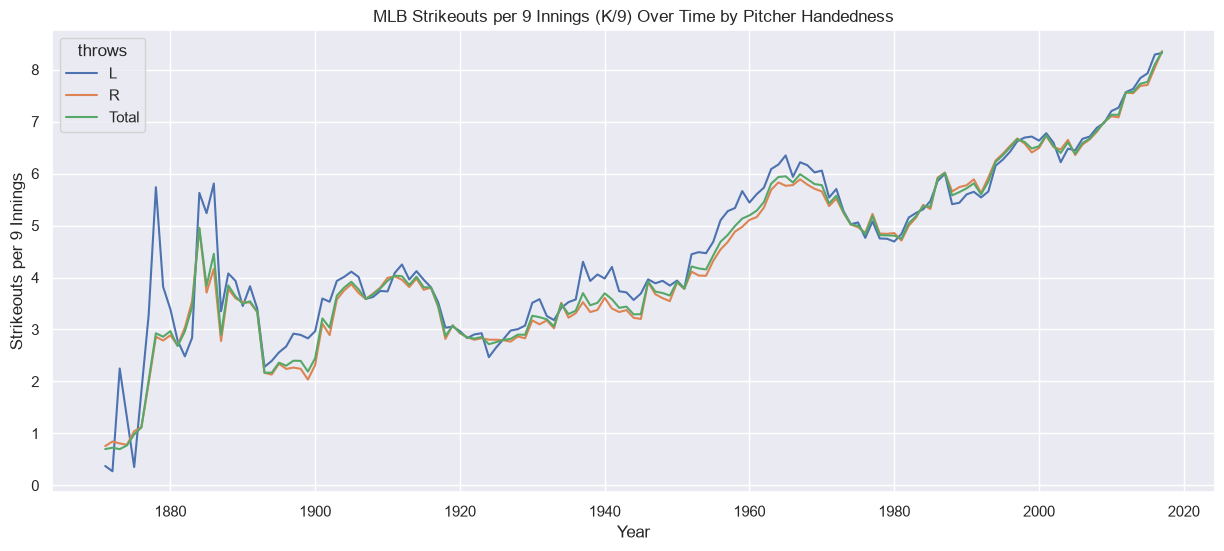

In [3]:
# Load the pitching and people data
pitching = pd.read_csv('core/Pitching.csv')
people = pd.read_csv('core/People.csv')

# Merge to get the 'throws' (handedness) column for each player
pitching_merged = pd.merge(pitching, people[['playerID', 'throws']], on='playerID', how='left')

# Filter out rows with 0 IPouts to avoid division by zero errors
pitching_merged = pitching_merged[pitching_merged['IPouts'] > 0]

# 1. Calculate the Total K/9 per year
total_yearly = pitching_merged.groupby('yearID')[['SO', 'IPouts']].sum().reset_index()
total_yearly['K9'] = (total_yearly['SO'] * 27) / total_yearly['IPouts']
total_yearly['throws'] = 'Total'  # Custom label for the legend

# 2. Calculate the K/9 per year grouped by handedness (L, R)
handed_yearly = pitching_merged.groupby(['yearID', 'throws'])[['SO', 'IPouts']].sum().reset_index()
handed_yearly['K9'] = (handed_yearly['SO'] * 27) / handed_yearly['IPouts']

# 3. Combine both dataframes so we can plot them all together
plot_data = pd.concat([handed_yearly, total_yearly], ignore_index=True)

# 4. Set the figure size using Seaborn
sns.set_theme(rc={'figure.figsize': (15, 6)})

# 5. Plot a line chart using Seaborn
ax = sns.lineplot(data=plot_data[plot_data['throws'].isin(['Total', 'L', 'R'])], x='yearID', y='K9', hue='throws')

# 6. Format the chart directly through the Seaborn axes object
ax.set_title('MLB Strikeouts per 9 Innings (K/9) Over Time by Pitcher Handedness')
ax.set_ylabel('Strikeouts per 9 Innings')
ax.set_xlabel('Year')

## Analysis Technique 3 - Do pitchers win more awards than hitters?

In [3]:
pitchers = pd.read_csv('core/Pitching.csv')
batters = pd.read_csv('core/Batting.csv')
awards = pd.read_csv('core/AwardsPlayers.csv')

In [5]:
# Many batters pitched, and vice versa. To better separate into more distinct groups, 
# I only keep players that won awards, and if the player pitched the year they won
# an award, they are counted as a pitcher. Otherwise, they are a batter.

pitchers_unique = pitchers[['playerID', 'yearID']].drop_duplicates(subset=['playerID', 'yearID'])
pitchers_unique

,playerID,yearID
0,bechtge01,1871
1,brainas01,1871
2,fergubo01,1871
3,fishech01,1871
4,fleetfr01,1871
...,...,...
45801,youngch03,2017
45802,zastrro01,2017
45803,zieglbr01,2017
45804,zimmejo02,2017


In [6]:
# add a column for whether the player has pitched that year or not for later joining
pitchers_unique['is_pitcher'] = 1
pitchers_unique


,playerID,yearID,is_pitcher
0,bechtge01,1871,1
1,brainas01,1871,1
2,fergubo01,1871,1
3,fishech01,1871,1
4,fleetfr01,1871,1
...,...,...,...
45801,youngch03,2017,1
45802,zastrro01,2017,1
45803,zieglbr01,2017,1
45804,zimmejo02,2017,1


In [10]:
# merge the awards with the pitchers, then replace any nans for is_pitcher with 0 
# which represents batters for that year. This should exclude any non-award winning
# players. Added role column for better readability
pitcher_awards_merge = pd.merge(awards, pitchers_unique, on=['playerID', 'yearID'], how='left')
pitcher_awards_merge['is_pitcher'] = pitcher_awards_merge['is_pitcher'].fillna(0)
pitcher_awards_merge['role'] = pitcher_awards_merge['is_pitcher'].map({1: 'Pitcher', 0: 'Batter'})
pitcher_awards_merge

,playerID,awardID,yearID,lgID,tie,notes,is_pitcher,role
0,bondto01,Pitching Triple Crown,1877,NL,NaN,NaN,1.0,Pitcher
1,hinespa01,Triple Crown,1878,NL,NaN,NaN,0.0,Batter
2,heckegu01,Pitching Triple Crown,1884,AA,NaN,NaN,1.0,Pitcher
3,radboch01,Pitching Triple Crown,1884,NL,NaN,NaN,1.0,Pitcher
4,oneilti01,Triple Crown,1887,AA,NaN,NaN,0.0,Batter
...,...,...,...,...,...,...,...,...
6231,stantmi03,TSN All-Star,2017,NL,NaN,OF,0.0,Batter
6232,blackch02,TSN All-Star,2017,NL,NaN,OF,0.0,Batter
6233,ozunama01,TSN All-Star,2017,NL,NaN,OF,0.0,Batter
6234,scherma01,TSN All-Star,2017,NL,NaN,SP,1.0,Pitcher


In [11]:
# merge the awards by year and role to get a count of awards won by group for each year
pitcher_awards = pitcher_awards_merge.groupby(['yearID', 'role']).size().reset_index(name='award_count')
pitcher_awards

,yearID,role,award_count
0,1877,Pitcher,1
1,1878,Batter,1
2,1884,Pitcher,2
3,1887,Batter,1
4,1888,Pitcher,1
...,...,...,...
226,2015,Pitcher,8
227,2016,Batter,61
228,2016,Pitcher,19
229,2017,Batter,62


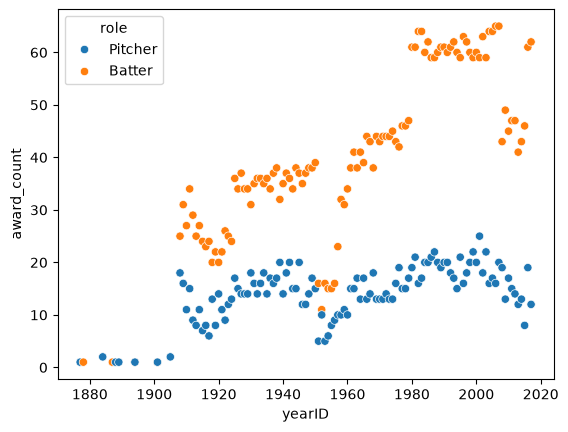

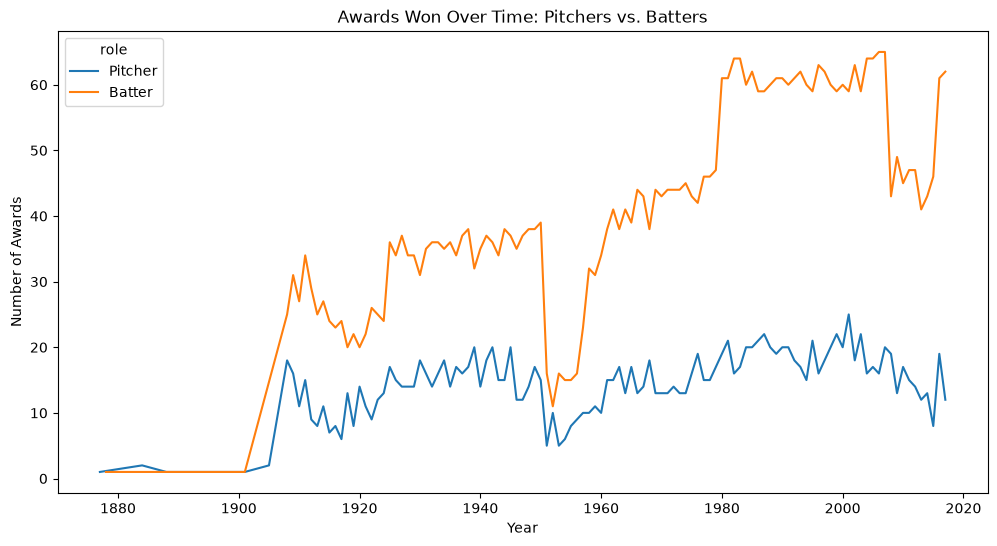

In [16]:
sns.scatterplot(data=pitcher_awards, x='yearID', y='award_count', hue='role')


plt.figure(figsize=(12, 6))
sns.lineplot(data=pitcher_awards, x='yearID', y='award_count', hue='role')
plt.title('Awards Won Over Time: Pitchers vs. Batters')
plt.xlabel('Year')
plt.ylabel('Number of Awards')
plt.show()

In [ ]:
# Notes: More awards for other positions relative to pitchers, fewer pitching awards in general
# Includes any player that pitched and won an award-may not be their primary role
# 

## Analysis Technique 4 - Team errors vs Bases Stolen

In [21]:
teams = pd.read_csv('core/Teams.csv')
teams_subset[['yearID','teamID','E', 'SB']] 
teams_subset

,yearID,teamID,E,SB
0,1871,BS1,243,73.0
1,1871,CH1,229,69.0
2,1871,CL1,234,18.0
3,1871,FW1,163,16.0
4,1871,NY2,235,46.0
...,...,...,...,...
2860,2017,SLN,94,81.0
2861,2017,TBA,100,88.0
2862,2017,TEX,108,113.0
2863,2017,TOR,92,53.0


In [28]:
# check for null values
teams_subset.isna().sum()

yearID      0
teamID      0
E           0
SB        126
dtype: int64

In [ ]:
# Drop null values 
teams_subset = teams_subset.dropna()
teams_subset 

<Axes: xlabel='E', ylabel='SB'>

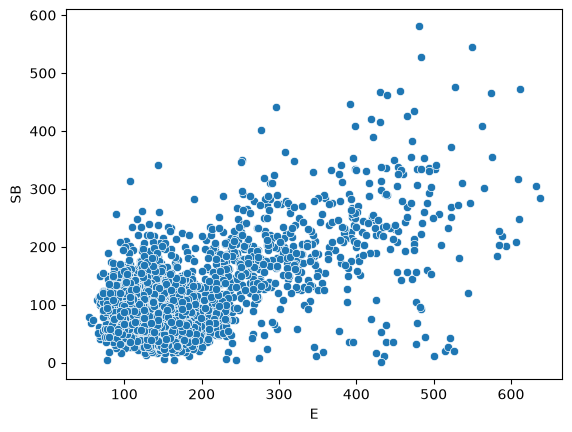

In [30]:
sns.scatterplot(data=teams_subset, x='E', y='SB')

<Axes: xlabel='E', ylabel='SB'>

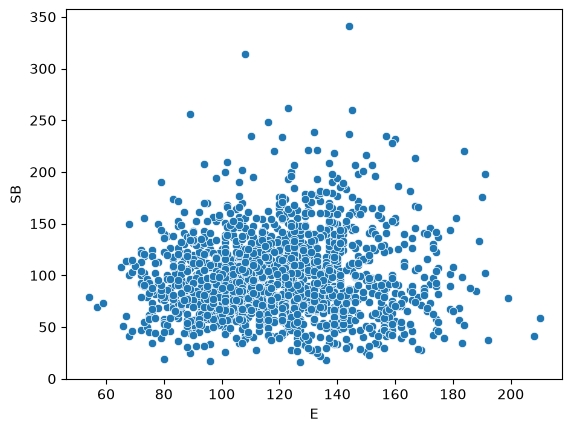

In [33]:
after_1960 = teams_subset[teams_subset['yearID'] >= 1960]
sns.scatterplot(data=after_1960, x='E', y='SB')